## Face recognition

In [4]:
from __future__ import absolute_import, division, print_function, unicode_literals
from tensorflow.python.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D,ZeroPadding2D,Dropout,Softmax
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.python.keras import Sequential
from sklearn.datasets import fetch_lfw_people
from sklearn.datasets import fetch_lfw_pairs
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
#!pip install scikit-plot
import scikitplot as skplt
import numpy as np
import random
import pandas as pd

# Commented out IPython magic to ensure Python compatibility.
import tensorflow_datasets as tfds
import tensorflow as tf

## Prepare Training

El dataset contiene imágenes de 19 personas, no obstante para cada una de ellas hay un número de imágenes diferente. Se escogen solo las personas que tengan 100 imágenes o más.

In [5]:
data = fetch_lfw_people(min_faces_per_person=100, resize=1.0, slice_=(slice(60, 188), slice(60, 188)), color=True)

class_count = len(data.target_names)

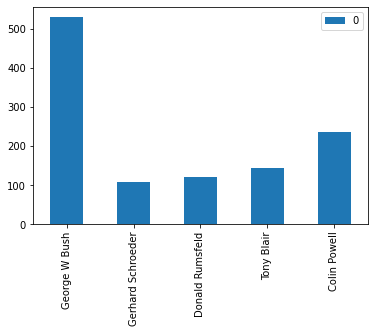

In [6]:
from collections import Counter
counts = Counter(data.target)
names = {}

for key in counts.keys():
    names[data.target_names[key]] = counts[key]

df = pd.DataFrame.from_dict(names, orient='index')
df.plot(kind='bar')

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

fig, ax = plt.subplots(3, 6, figsize=(18, 10))

for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i] / 255) # Scale pixel values so Matplotlib doesn't clip everything above 1.0
    axi.set(xticks=[], yticks=[], xlabel=faces.target_names[faces.target[i]])

## Balancing the data

Los modelos de clasificación se entrenan mejor con datasets que estén balanceados. Es por ello que se utilizan 100 imágenes para cada persona.

In [9]:
mask = np.zeros(data.target.shape, dtype=np.bool)

for target in np.unique(data.target):
    mask[np.where(data.target == target)[0][:100]] = 1

x_faces = data.data[mask]
y_faces = data.target[mask]
x_faces = np.reshape(x_faces, (x_faces.shape[0], data.images.shape[1], data.images.shape[2], data.images.shape[3]))
x_faces.shape

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  This is separate from the ipykernel package so we can avoid doing imports until


(500, 128, 128, 3)

In [10]:
####### Train and test splitting of data #######

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split

face_images = preprocess_input(np.array(x_faces))
face_labels = to_categorical(y_faces)

x_train, x_test, y_train, y_test = train_test_split(face_images, face_labels, train_size=0.8, stratify=face_labels, random_state=0)

## Use transfer learning with ResNet50 and ImageNet weights

El primer modelo emplea transfer learning con ResNet50 con pesos calculados de una red entranada con más de 1 millón de imágenes del dataset de ImageNet. Se empieza por cargar ResNet50 sin las capas de clasificación y congelando las capas del cuello de botella

In [60]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False)
base_model.trainable = False

Se añaden las capas de clasificación al modelo de base y se incluye una capa de reajuste para redimensionar las imagenes puestas como entrada a la red a 224x224

In [66]:
from keras.models import Sequential
from keras.layers import Flatten, Dense, Resizing

model = Sequential()
model.add(Resizing(224, 224))
model.add(base_model)
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dense(class_count, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [67]:
import time

start_time = time.time()
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=10, epochs=10)
end_time = time.time()

print("###### Total Time Taken: ", round((end_time - start_time)/60), 'Minutes ######')

Epoch 1/10
40/40 [==============================] - 176s 4s/step - loss: 21.3258 - accuracy: 0.6200 - val_loss: 2.0520 - val_accuracy: 0.8800
Epoch 2/10
40/40 [==============================] - 100s 3s/step - loss: 1.1489 - accuracy: 0.9550 - val_loss: 2.5406 - val_accuracy: 0.9100
Epoch 3/10
40/40 [==============================] - 98s 2s/step - loss: 0.2706 - accuracy: 0.9800 - val_loss: 4.1260 - val_accuracy: 0.9000
Epoch 4/10
40/40 [==============================] - 105s 3s/step - loss: 0.1052 - accuracy: 0.9900 - val_loss: 3.2363 - val_accuracy: 0.9300
Epoch 5/10
40/40 [==============================] - 107s 3s/step - loss: 8.9407e-09 - accuracy: 1.0000 - val_loss: 3.2151 - val_accuracy: 0.9300
Epoch 6/10
40/40 [==============================] - 100s 3s/step - loss: 9.5367e-09 - accuracy: 1.0000 - val_loss: 3.2151 - val_accuracy: 0.9300
Epoch 7/10
40/40 [==============================] - 97s 2s/step - loss: 8.9407e-09 - accuracy: 1.0000 - val_loss: 3.2151 - val_accuracy: 0.9300
Ep

[]

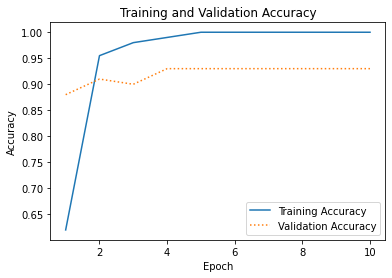

In [70]:
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, '-', label='Training Accuracy')
plt.plot(epochs, val_acc, ':', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.plot()

## Use transfer learning with ResNet50 and VGGFace2 weights

Inicializada con pesos de ImageNet, ResNet50 logra una precisión de alrededor del 90 % en el reconocimiento  en el conjunto de datos de LFW. Pero los pesos de ImageNet se generaron entrenando la red con imágenes de cientos de objetos diferentes. Estos pesos no están optimizados para extraer características de las caras.

keras-vggface es un paquete de Python que modela CNN preentrenadas para reconocer las caras de personas famosas. Estas CNN (y sus pesos) están encapsuladas en una clase denominada VGGFace. Se cargan las capas de cuello de botella de la versión ResNet50 de VGGFace junto con los pesos a los que se llegó cuando se entrenó con más de 3 millones de imágenes en el conjunto de datos VGGFace2 y se usa el transfer learning para entrenar la red resultante en el conjunto de datos LFW. Como antes, se comienza por cargar VGGFace sin las capas de clasificación y congelando las capas de cuello de botella.

In [1]:
!pip install git+https://github.com/rcmalli/keras-vggface.git
!pip install keras_applications --no-deps
filename = "/usr/local/lib/python3.7/dist-packages/keras_vggface/models.py"
text = open(filename).read()
open(filename, "w+").write(text.replace('keras.engine.topology', 'tensorflow.keras.utils'))
import tensorflow as tf

from keras_vggface.vggface import VGGFace

base_model = VGGFace(model='resnet50', include_top=False)
base_model.trainable = False

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/rcmalli/keras-vggface.git to /tmp/pip-req-build-7d449lnt
  Running command git clone -q https://github.com/rcmalli/keras-vggface.git /tmp/pip-req-build-7d449lnt
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
94694792/94694792 [==============================] - 1s 0us/step


Se añaden las capas de clasificación al modelo de base y se incluye una capa de reajuste para redimensionar las imagenes puestas como entrada a la red a 224x224

In [7]:
from keras.models import Sequential
from keras.layers import Flatten, Dense, Resizing

model = Sequential()
model.add(Resizing(224, 224))
model.add(base_model)
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dense(class_count, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [11]:
import time

start_time = time.time()
hist = model.fit(x_train, y_train, validation_data=(x_test, y_test), batch_size=10, epochs=10)
end_time = time.time()

print("###### Total Time Taken: ", round((end_time - start_time)/60), 'Minutes ######')

Epoch 1/10
40/40 [==============================] - 80s 2s/step - loss: 0.5428 - accuracy: 0.9425 - val_loss: 2.2373e-04 - val_accuracy: 1.0000
Epoch 2/10
40/40 [==============================] - 71s 2s/step - loss: 0.0273 - accuracy: 0.9975 - val_loss: 5.2452e-08 - val_accuracy: 1.0000
Epoch 3/10
40/40 [==============================] - 74s 2s/step - loss: 0.0545 - accuracy: 0.9950 - val_loss: 1.0758e-04 - val_accuracy: 1.0000
Epoch 4/10
40/40 [==============================] - 76s 2s/step - loss: 3.1545e-04 - accuracy: 1.0000 - val_loss: 7.3073e-07 - val_accuracy: 1.0000
Epoch 5/10
40/40 [==============================] - 71s 2s/step - loss: 3.5763e-09 - accuracy: 1.0000 - val_loss: 4.4345e-07 - val_accuracy: 1.0000
Epoch 6/10
40/40 [==============================] - 74s 2s/step - loss: 3.2783e-09 - accuracy: 1.0000 - val_loss: 4.3868e-07 - val_accuracy: 1.0000
Epoch 7/10
40/40 [==============================] - 75s 2s/step - loss: 2.9802e-09 - accuracy: 1.0000 - val_loss: 4.3630e-07

[]

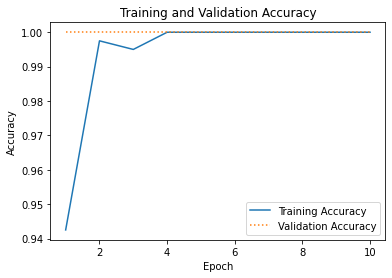

In [12]:
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, '-', label='Training Accuracy')
plt.plot(epochs, val_acc, ':', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.plot()


In [13]:
score = model.evaluate(x_train,y_train,verbose=0)
print(score[1]*100)

100.0
